In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical

👉 These are building blocks of CNN:
Conv2D → detects features in image
MaxPooling2D → reduces image size
Flatten → converts to 1D
Dense → normal neural layer
Dropout → prevents overfitting
Input → defines input shape

Converts labels into one-hot encoding

In [2]:
# ── 1. Class names ──
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
                'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']

# ── 2. Load dataset ──
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step 
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
# ── 3. Save labels before one-hot encoding ──
y_train_labels = y_train.copy()
y_test_labels  = y_test.copy()

# ── 4. Normalize (0-255 → 0-1) ──
X_train = X_train / 255.0
X_test  = X_test  / 255.0

# ── 5. Reshape for CNN ──
X_train = X_train.reshape(-1, 28, 28, 1) #CNNs require a 4D input: (Number of images, Height, Width, Channels). Since these are grayscale, we add 1 for the channel. (RGB would be 3).
X_test  = X_test.reshape(-1, 28, 28, 1)

# ── 6. One-hot encode labels ──
y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test,  10)

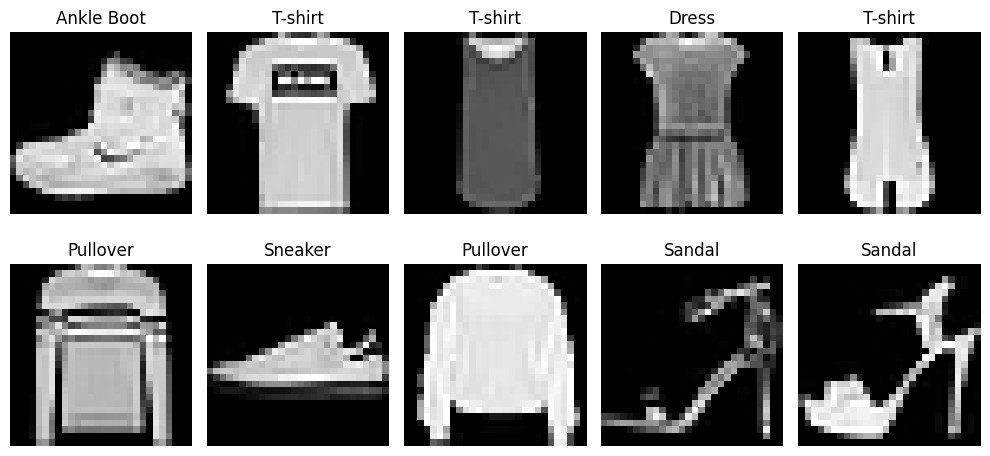

In [4]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    plt.title(class_names[y_train_labels[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [5]:
# ── 8. Build model ──
model = Sequential([
    Input(shape=(28, 28, 1)),   # ✅ correct way

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(), #2D image → 1D vector
    Dense(128, activation='relu'),
    Dropout(0.5), #Randomly turns off 50% neurons, Prevents overfitting
    Dense(10, activation='softmax') # Softmax → gives probabilities
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# ── 9. Compile ── Adam: An smart "accelerator" that adjusts learning rates automatically.Categorical Crossentropy: The standard math used to calculate "error" for multiple categories.

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ── 10. Train ──
history = model.fit(X_train, y_train,
                    epochs=5,
                    batch_size=128,
                    validation_data=(X_test, y_test))

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.7607 - loss: 0.6615 - val_accuracy: 0.8455 - val_loss: 0.4198
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.8472 - loss: 0.4248 - val_accuracy: 0.8723 - val_loss: 0.3536
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.8680 - loss: 0.3676 - val_accuracy: 0.8847 - val_loss: 0.3178
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.8800 - loss: 0.3325 - val_accuracy: 0.8862 - val_loss: 0.3146
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.8872 - loss: 0.3120 - val_accuracy: 0.8957 - val_loss: 0.2865


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8957 - loss: 0.2865
Test Accuracy: 0.8957
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step  


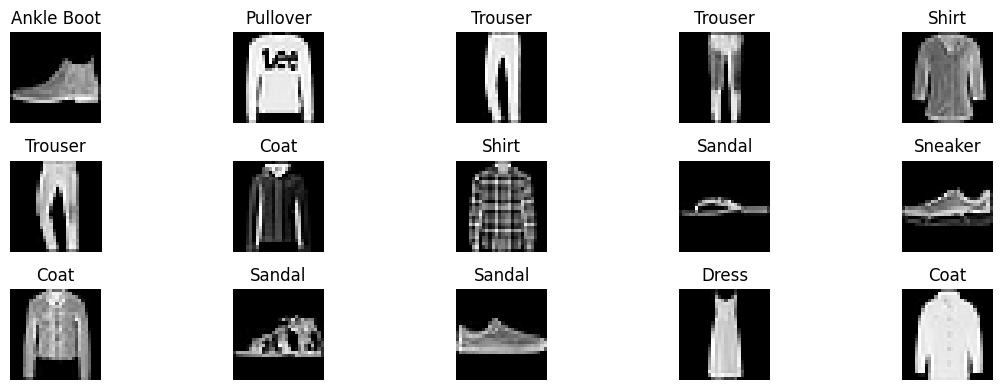

In [10]:
# ── 11. Evaluate ──
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

# ── 12. Predict and show results ──
predictions = model.predict(X_test)

plt.figure(figsize=(12, 4))

for i in range(15):  
    plt.subplot(3, 5, i + 1)   
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(class_names[np.argmax(predictions[i])]) #👉 Gets highest probability index-argmax
    plt.axis('off')

plt.tight_layout()
plt.show()

# np.argmax: This is the most important part. It finds the index of the highest number in the probability array. If index 2 had the 95% probability, argmax returns 2.
# class_names[...]: It takes that index (2) and looks up the name (e.g., "Pullover") to use as the title for that image.